In [45]:
%pip install pandas numpy astropy netCDF4 matplotlib scikit-learn seaborn GeoPandas shapely pyproj
# makes seaborn work in notebooks
%matplotlib inline 

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [46]:
site = "St Austell" #"Tongariro" # Change this
band_mapping_file = "instrument_band_parameters.csv"
# Get this from a spectral signature database
spectral_signatures_file = "spectral_signatures.csv"

minerals_to_plot_bg = ("Kaolinite",) # St Austell
# minerals_to_plot_bg = ("Kaolinite", "Smectite", "Illite") # Ruapehu

roi_file = "St_Asutell_feaure_masks.geojson" #"Tongariro_feature_masks.geojson" # Change this


image_files = {
    # Change this
    # "Before": f"{site}/Derivatives/tongariro-before-clipped.tif",
    # "After": f"{site}/Derivatives/tongariro-after-clipped.tif"
    "Before": f"{site}/Derivatives/St_austell_pre_storm_clipped_no-water.tif",
    "After": f"{site}/Derivatives/St_austell_post_storm_clipped_no-water.tif"
}

import numpy as np
import pandas as pd
import rasterio
from astropy.visualization import make_lupton_rgb
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from rasterio.features import geometry_mask
import re

plt.ion()

images = {}
for key in image_files.keys():
    image = rasterio.open(image_files[key])
    print(f"Loaded {key} data. ({image.count} bands)")
    images[key] = image
n_bands = next(iter(images.values())).count


band_params = pd.read_csv(band_mapping_file)

wavelengths = band_params["wavelength_center"].to_numpy()
good = band_params["good_wavelength"].astype(bool).to_numpy()


sig_raw = pd.read_csv(spectral_signatures_file)
print(sig_raw)

first_col = sig_raw.columns[0]
signatures = sig_raw.rename(columns={
    first_col: "wavelength_nm",
})
print(band_params)
if len(band_params) != n_bands:
    raise ValueError(
        f"Wavelength table has {len(band_params)} bands, "
        f"but TIFF has {n_bands} bands."
    )
signature_cols = ["Kaolinite", "Smectite", "Illite"]
signatures = signatures[["wavelength_nm"] + signature_cols].copy()

signatures["wavelength_nm"] = pd.to_numeric(
    signatures["wavelength_nm"],
    errors="coerce"
)

for col in signature_cols:
    signatures[col] = pd.to_numeric(signatures[col], errors="coerce")

signatures = signatures.dropna(subset=["wavelength_nm"])

def as_mineral_list(minerals):
    """
    Accepts:
        "Kaolinite"
        ["Kaolinite", "Illite"]
        ("Kaolinite",)
    and always returns a list.
    """
    if minerals is None:
        return ["Kaolinite", "Smectite", "Illite"]

    if isinstance(minerals, str):
        return [minerals]

    return list(minerals)


def add_signature_background(
    ax,
    minerals=None,
    alpha=0.22,
    linewidth=1.4,
    normalize=True,
):
    """
    Add selected mineral spectral signatures behind an reflectance graph.

    Assumes the main plot x-axis is wavelength in nm.

    Returns the secondary axis so its legend entries can be merged.
    """

    minerals = as_mineral_list(minerals)

    alpha = float(np.ravel([alpha])[0])
    linewidth = float(np.ravel([linewidth])[0])

    ax2 = ax.twinx()

    ax.set_zorder(2)
    ax2.set_zorder(1)
    ax.patch.set_alpha(0)

    x_nm = signatures["wavelength_nm"].to_numpy(dtype=float)

    for mineral in minerals:
        if mineral not in signatures.columns:
            raise ValueError(
                f"'{mineral}' not found in signatures. "
                f"Available columns are: {list(signatures.columns)}"
            )

        y = signatures[mineral].to_numpy(dtype=float)

        y = np.where(y > 0, y, np.nan)
        y = -np.log10(y)

        if normalize:
            ymin = np.nanmin(y)
            ymax = np.nanmax(y)

            if np.isfinite(ymin) and np.isfinite(ymax) and ymax > ymin:
                y = (y - ymin) / (ymax - ymin)

        valid = np.isfinite(x_nm) & np.isfinite(y)

        ax2.plot(
            x_nm[valid],
            y[valid],
            linestyle="--",
            linewidth=linewidth,
            alpha=alpha,
            label=f"{mineral} signature"
        )

    if normalize:
        ax2.set_ylim(0, 1)

    ax2.tick_params(right=False, labelright=False)
    ax2.set_ylabel("")

    for spine in ax2.spines.values():
        spine.set_visible(False)

    return ax2

Loaded Before data. (285 bands)
Loaded After data. (285 bands)
      Unnamed: 0  Kaolinite  Unnamed: 2  Smectite  Unnamed: 4  Illite
0            350      0.391         350     0.519         350   0.143
1            351      0.395         351     0.520         351   0.144
2            352      0.399         352     0.522         352   0.145
3            353      0.404         353     0.522         353   0.146
4            354      0.409         354     0.523         354   0.147
...          ...        ...         ...       ...         ...     ...
2146        2496      0.223        2496     0.314        2496   0.363
2147        2497      0.223        2497     0.314        2497   0.363
2148        2498      0.223        2498     0.313        2498   0.363
2149        2499      0.223        2499     0.312        2499   0.364
2150        2500      0.223        2500     0.311        2500   0.364

[2151 rows x 6 columns]
     band  wavelength_center   fwhm  good_wavelength
0       1          

(285, 162, 228)
(285, 134, 294)


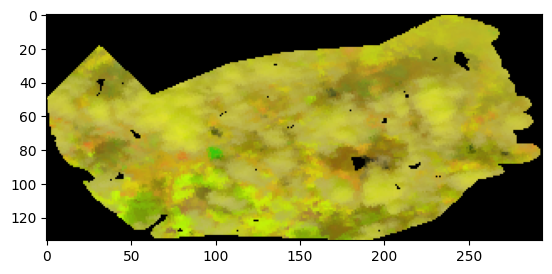

In [47]:
plt.clf()

image_data = {}
for key in images.keys():
    bd = images[key].read(masked=True)
    image_data[key] = bd
    print(bd.shape) # (band, row, col)
    plt.imshow(make_lupton_rgb(bd[120],bd[60], bd[280],stretch=0.1))
    # plt.imshow(make_lupton_rgb(bd[20],bd[200], bd[80],stretch=0.1))

(380.85788, 2492.7761)

<Figure size 640x480 with 0 Axes>

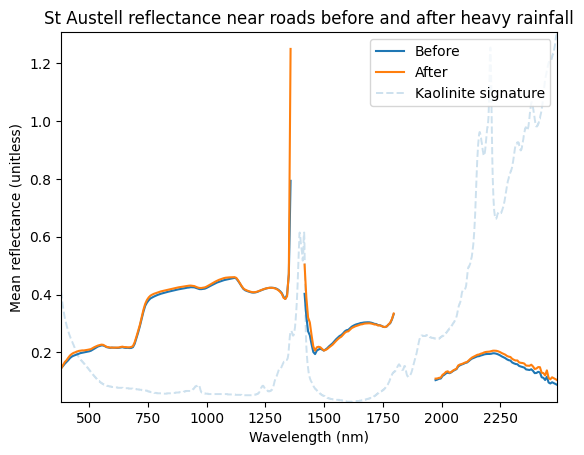

In [48]:
plt.clf()
fig, ax = plt.subplots()
sig_ax = add_signature_background(
    ax,
    minerals=minerals_to_plot_bg
)
avg_reflectances = {}
for key in image_data.keys():
    bd = image_data[key]
    avg = np.nanmean(bd, axis=(1,2))
    avg[~good] = np.nan
    avg_reflectances[key] = avg
    ax.plot(wavelengths,avg,label=key)

# Merge reflectance lines and background-signature lines into one legend
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = sig_ax.get_legend_handles_labels()

ax.legend(
    h1 + h2,
    l1 + l2,
    loc="best"
)

ax.set_title(f"{site} reflectance near roads before and after heavy rainfall")
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Mean reflectance (unitless)")
ax.set_xlim(np.nanmin(wavelengths[good]), np.nanmax(wavelengths[good]))# plt.xlim(127, 132)

Text(0, 0.5, 'Mean reflectance difference (unitless)')

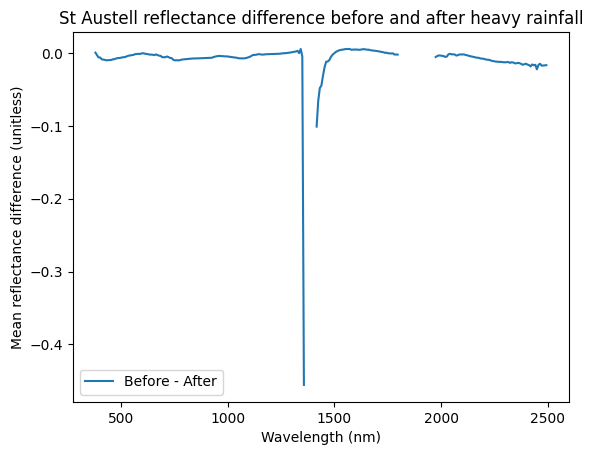

In [49]:
diff = avg_reflectances["Before"] - avg_reflectances["After"]
diff[~good] = np.nan
plt.clf()
plt.plot(wavelengths, diff, label="Before - After")
plt.legend()
plt.title(f"{site} reflectance difference before and after heavy rainfall")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Mean reflectance difference (unitless)")

In [50]:
feature_col = "Feature"


rois = gpd.read_file(roi_file)
if feature_col not in rois.columns:
    print(f"Missing '{feature_col}' field")

rois = rois[rois.geometry.notna() & ~rois.geometry.is_empty].copy()
print(rois[[feature_col, "geometry"]].head())
print(rois.describe())
print(f"\nCRS: {rois.crs}")

      Feature                                           geometry
0         Pit  POLYGON ((-4.93312 50.37064, -4.93296 50.36777...
1         Pit  POLYGON ((-4.92054 50.38935, -4.92054 50.38872...
2         Pit  POLYGON ((-4.92229 50.37789, -4.92412 50.37813...
3       Solar  POLYGON ((-4.90097 50.36026, -4.90064 50.35965...
4  Industrial  POLYGON ((-4.89524 50.36964, -4.89485 50.36911...
       Feature                                           geometry
count       35                                                 35
unique       4                                                 35
top        Pit  POLYGON ((-4.933118492542795 50.37064059082159...
freq        21                                                  1

CRS: EPSG:4278


<Figure size 640x480 with 0 Axes>

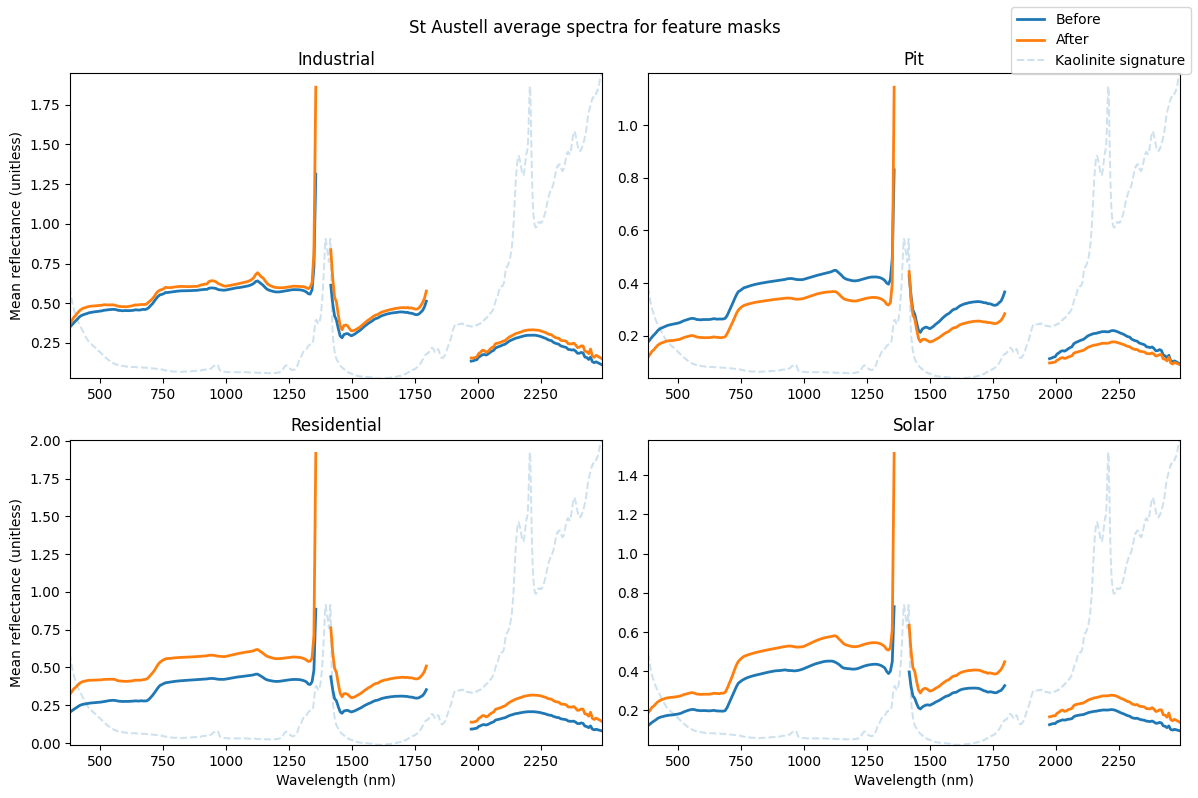

In [51]:
plt.clf()

results = []
for key in image_data.keys():

    data = image_data[key]
    img = images[key]

    rois_for_img = rois.to_crs(img.crs)


    for feature_name, group in rois_for_img.groupby("Feature"):
        poly_mask = geometry_mask(
            group.geometry,
            out_shape=(img.height, img.width),
            transform=img.transform,
            invert=True,          # True inside polygons
            all_touched=False
        )

        # Keep only pixels inside polygons that have finite values in at least one band.
        valid_mask = poly_mask & np.any(np.isfinite(data), axis=0)

        n_pixels = int(valid_mask.sum())
        if n_pixels == 0:
            print(f"Warning: no raster pixels found for feature '{feature_name}'")
            continue

        masked_data = np.where(valid_mask[None, :, :], data, np.nan)
        avg = np.nanmean(masked_data, axis=(1,2))

        for band_idx, value in enumerate(avg, start=1):
            results.append({
                "image":key,
                "Feature": feature_name,
                "good_wavelength": good[band_idx-1],
                "wavelength": wavelengths[band_idx-1],
                "band": band_idx,
                "avg_reflectance": value,
                "n_pixels": n_pixels
            })


width = 2
height = 2

fig, axs = plt.subplots(height, width, figsize=(12, 8), squeeze=False)

#### Change this ####
diff = False
####################

dataframe = pd.DataFrame(results)

features = dataframe["Feature"].unique()

# Easier to drop it here than in the GIS dataset
features = np.delete(features, np.where(features == "Forestry"))

legend_handles = []
legend_labels = []

i = 0

for j in range(height):
    for k in range(width):
        ax = axs[j, k]

        if i >= len(features):
            ax.set_axis_off()
            continue

        feature = features[i]
        i += 1

        feat_data = dataframe.loc[dataframe["Feature"] == feature].copy()

        before_data = (
            feat_data.loc[feat_data["image"] == "Before"]
            .sort_values("band")
            .copy()
        )

        after_data = (
            feat_data.loc[feat_data["image"] == "After"]
            .sort_values("band")
            .copy()
        )

        if not diff:
            sig_ax = add_signature_background(
                ax,
                minerals=minerals_to_plot_bg
            )

        if diff:
            diff_df = before_data.merge(
                after_data,
                on="band",
                suffixes=("_before", "_after")
            )

            diff_df["reflectance_diff"] = (
                diff_df["avg_reflectance_before"]
                - diff_df["avg_reflectance_after"]
            )

            diff_df.loc[~diff_df["good_wavelength_before"], "reflectance_diff"] = np.nan

            ax.plot(
                diff_df["wavelength_before"],
                diff_df["reflectance_diff"],
                label="Before - After",
                linewidth=2
            )

        else:
            before_y = before_data["avg_reflectance"].where(
                before_data["good_wavelength"]
            )

            after_y = after_data["avg_reflectance"].where(
                after_data["good_wavelength"]
            )

            ax.plot(
                before_data["wavelength"],
                before_y,
                label="Before",
                linewidth=2
            )

            ax.plot(
                after_data["wavelength"],
                after_y,
                label="After",
                linewidth=2
            )

        ax.set_title(feature)

        if j == height - 1:
            ax.set_xlabel("Wavelength (nm)")

        if k == 0:
            ax.set_ylabel(
                "Mean reflectance" + ("" if not diff else " difference") + " (unitless)"
            )

        ax.set_xlim(
            np.nanmin(wavelengths[good]),
            np.nanmax(wavelengths[good])
        )

        # Collect legend entries from this subplot
        h1, l1 = ax.get_legend_handles_labels()
        legend_handles.extend(h1)
        legend_labels.extend(l1)

        if not diff:
            h2, l2 = sig_ax.get_legend_handles_labels()
            legend_handles.extend(h2)
            legend_labels.extend(l2)


# Deduplicate legend labels while preserving order
legend_dict = {}

for handle, label in zip(legend_handles, legend_labels):
    if label not in legend_dict:
        legend_dict[label] = handle

fig.legend(
    legend_dict.values(),
    legend_dict.keys(),
    loc="upper right"
)

fig.suptitle(
    f"{site} average spectra"
    f"{' differences ' if diff else ' '}"
    f"for feature masks"
)

fig.tight_layout()
plt.show()

In [52]:
from rasterio.plot import plotting_extent

bd = image_data["Before"]

plt.clf()
plt.imshow(
    make_lupton_rgb(bd[30], bd[200], bd[80], stretch=0.1),
    extent=plotting_extent(src)
)

rois.to_crs(src.crs).boundary.plot(ax=plt.gca(), linewidth=1, color="yellow")
plt.title(f"{site} POI polygons over raster")

NameError: name 'src' is not defined

<Figure size 640x480 with 0 Axes>